In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, RocCurveDisplay, roc_auc_score)

sns.set_style("whitegrid")

In [2]:
# Carregar o dataset
df = pd.read_csv("./hotel_bookings.csv")

In [3]:
# Inspeção Inicial
print(f"Tamanho do dataset: {df.shape[0]} linhas, {df.shape[1]} colunas")

# Verificar uma amostra dos dados
df.head()

Tamanho do dataset: 119390 linhas, 32 colunas


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [4]:
df.info() # Informações gerais do dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [5]:
tamanho_original = len(df) # Este valor será utilizado em futuras comparações para mensurar alterações no tamanho do database

# Registros com dados nulos:
print(f"Nulos:")
print(f"{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"\nTotal de registros nulos: {df.isnull().sum().sum()}")

# Registros com dados duplicados:
print(f"Registros duplicados: {df.duplicated().sum()}")

# Registros com ADR negativo:
print(f"Registros com ADR abaixo de 0: {len(df[(df['adr'] < 0)])}")

# Registros sem hóspedes:
print(f"Registros sem hóspedes: {len(df[(df['adults'] + df['children'] + df['babies']) <= 0])}")

# Algumas informações relevantes ao estudo dos dados:
print(f"\nTipos de Hotéis: {df['hotel'].unique()}")
print(f"\nTaxa de cancelamento: {df['is_canceled'].mean()*100:.1f}%")
print("Coluna target: is_canceled (0 = mantida, 1 = cancelada)")

Nulos:
children         4
country        488
agent        16340
company     112593
dtype: int64

Total de registros nulos: 129425
Registros duplicados: 31994
Registros com ADR abaixo de 0: 1
Registros sem hóspedes: 180

Tipos de Hotéis: ['Resort Hotel' 'City Hotel']

Taxa de cancelamento: 37.0%
Coluna target: is_canceled (0 = mantida, 1 = cancelada)


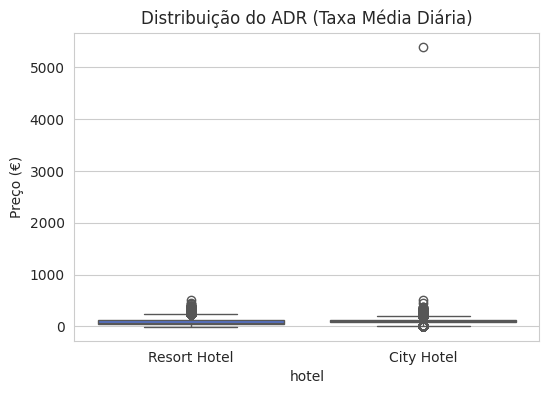

In [6]:
# Identificação de outliers Extremos com visualização gráfica (Boxplot)
adr = df['adr']
hotel_types = ['Resort Hotel', 'City Hotel']

plt.figure(figsize=(6, 4))
sns.boxplot(y=adr,x=df['hotel'], color='royalblue')
plt.title("Distribuição do ADR (Taxa Média Diária)")
plt.ylabel("Preço (€)")
plt.show()

In [7]:
# Remoção dos Outliers extremos
df = df[df['adr'] <= 1000]

tamanho_atual = len(df)
print(f"Linhas removidas: {tamanho_original - tamanho_atual}")

Linhas removidas: 1


In [8]:
# Remoção de registros duplicados
df = df.drop_duplicates()

# Tratamento dos nulos (coluna por coluna)
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna("Unknown") # País desconhecido
df['agent'] = df['agent'].fillna(0) # Sem agente
df['company'] = df['company'].fillna(0) # Sem empresa

print(f"Linhas removidas: {tamanho_atual - len(df)}")
tamanho_atual = len(df)
print(f"Nulos restantes: {df.isnull().sum().sum()}")


Linhas removidas: 31994
Nulos restantes: 0


In [9]:
# Remoção de valores impossíveis ADR(Valor Médio da Tarifa Diária)

df = df[df['adr'] >= 0] # Removidos os registros com ADR abaixo de 0

print(f"Linhas removidas: {tamanho_atual - len(df)}")
tamanho_atual = len(df)


Linhas removidas: 1


In [10]:
# Remoção de valores impossíveis - Quantidade de Hóspedes
df = df[(df['adults'] + df['children'] + df['babies']) > 0] # Removidos os registros que não possuem hóspedes

print(f"Linhas removidas: {tamanho_atual - len(df)}")
tamanho_atual = len(df)

Linhas removidas: 166


In [11]:
# Verificação do tamanho (linhas x colunas) do dataset após o tratamento dos dados:
print(f"Tamanho atualizado do dataset: {df.shape[0]} linhas, {df.shape[1]} colunas.")
print(f"Durante o tratamento do dados, {tamanho_original - df.shape[0]} linhas foram removidas.")

Tamanho atualizado do dataset: 87228 linhas, 32 colunas.
Durante o tratamento do dados, 32162 linhas foram removidas.


Gráficos

Reservas em City Hotels: 53273 (61.07%).
Reservas em Resort Hotels: 33955 (38.93%).


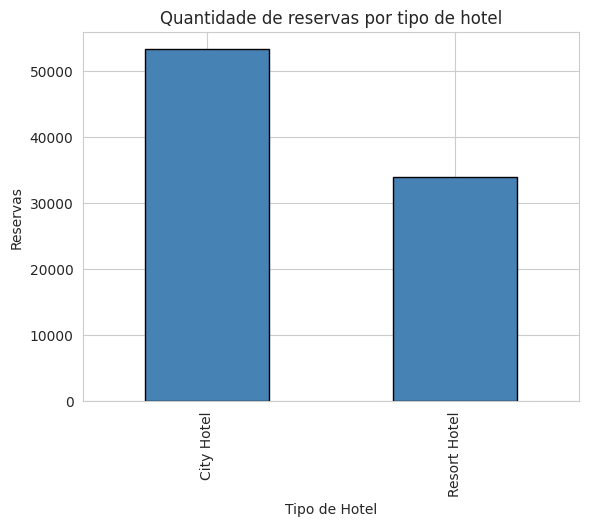

In [12]:
# Gráfico 1: Tipo de Hotel
hoteis = df['hotel'].value_counts()
#print(f"Teste: {hoteis}")
city = hoteis["City Hotel"]
resort = hoteis["Resort Hotel"]
total_registered = city + resort

print(f"Reservas em City Hotels: {city} ({(city / total_registered)*100:.2f}%).")
print(f"Reservas em Resort Hotels: {resort} ({(resort / total_registered)*100:.2f}%).")

df['hotel'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title("Quantidade de reservas por tipo de hotel")
plt.xlabel("Tipo de Hotel")
plt.ylabel("Reservas")
plt.show()

Gráfico 1:
City Hotels têm mais reservas que Resorts.
No dataset em uso, há 53.273 reservas em City Hotels (61,07%) e 33.955 reservas em Resorts (38,93%).


In [13]:
# Gráfico 2: Taxa de Cancelamento por Tipo de Hotel
cancel = df.groupby('hotel')['is_canceled'].mean() * 100
print(f"Reservas canceladas em City Hotels: {(cancel["City Hotel"]):.2f}%")
print(f"Reservas canceladas em Resorts: {(cancel["Resort Hotel"]):.2f}%")

Reservas canceladas em City Hotels: 30.10%
Reservas canceladas em Resorts: 23.48%


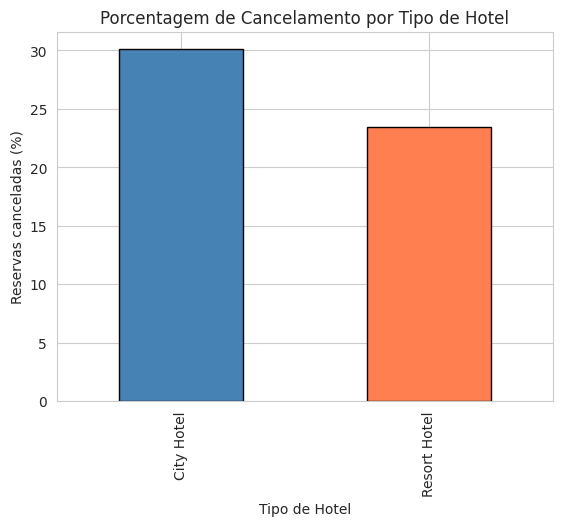

In [14]:
cancel.plot(kind='bar', color=['steelblue', 'coral'], edgecolor='black')
plt.title('Porcentagem de Cancelamento por Tipo de Hotel')
plt.xlabel("Tipo de Hotel")
plt.ylabel('Reservas canceladas (%)')
plt.show()


Gráfico 2: reservas em City Hotels cancelam mais que Resorts.
Na amostra de dados presente no dataset do projeto, City Hotels têm 30.10% de suas reservas canceladas, enquanto Resorts têm 23.45% de cancelamento.

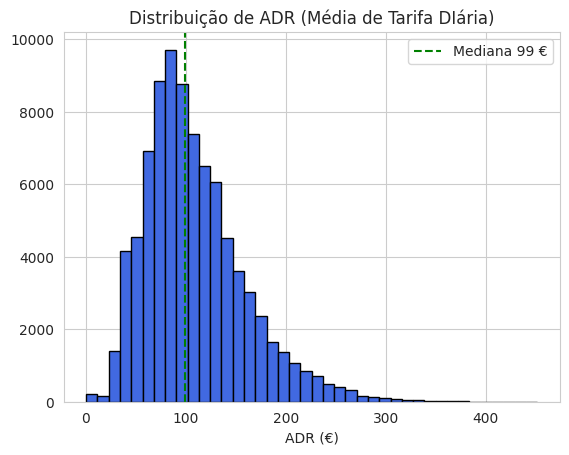

In [15]:
# Gráfico 3: Histograma de Tarifas
adr_filtrado = df['adr'][(df['adr'] > 0) & (df['adr'] < 500)]
plt.hist(adr_filtrado, bins=40, color='royalblue', edgecolor='black')
plt.title('Distribuição de ADR (Média de Tarifa DIária)')
plt.xlabel("ADR (€)")
plt.axvline(adr_filtrado.median(), color='green', linestyle='--', label=f'Mediana {adr_filtrado.median():.0f} €')
plt.legend()
plt.show()

Gráfico 3: A maioria das diárias está concentrada entre 50 a 150 euros, com a mediana em 99 €.

/tmp/ipykernel_4007/937749252.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='Set2')


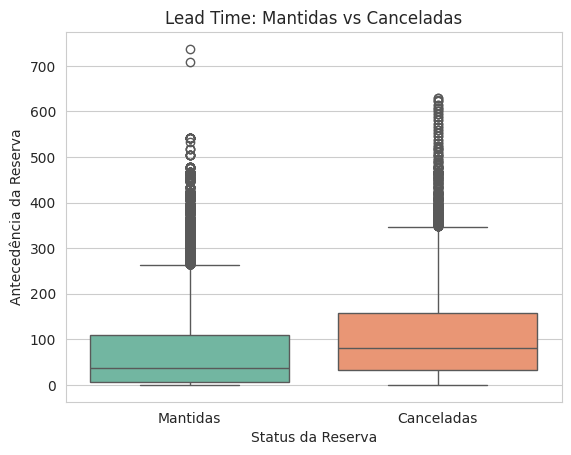

In [16]:
# Gráfico 4: Boxplot do lead time por cancelamento
sns.boxplot(data=df, x='is_canceled', y='lead_time', palette='Set2')
plt.xticks([0, 1], ['Mantidas', 'Canceladas'])
plt.title('Lead Time: Mantidas vs Canceladas')
plt.xlabel("Status da Reserva")
plt.ylabel("Antecedência da Reserva")
plt.show()


Gráfico 4: Reservas canceladas têm lead time (antecedência) maior. Reservas feitas com mais de 120 dias de antecedência (aproximadamente) apresentam uma taxa de cancelamento mais alta, representando maior risco de perda financeira ao hotel. Esse é um padrão forte e é bem provável que o algoritmo de ML que será treinado leve muito em consideração.

In [17]:
# Features criadas por combinações e derivações

df['total_noites'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']
df['total_hospedes'] = df['adults'] + df['children'] + df['babies']
meses_map = {
    "January" : 1, "February" : 2, "March" : 3, "April" : 4,
    "May" : 5, "June" : 6, "July": 7, "August" : 8, "September" : 9,
    "October" : 10, "November" : 11, "December" : 12
}

df['numero_mes'] = df['arrival_date_month'].map(meses_map)
df['alta_temporada'] = df['numero_mes'].isin([6, 7, 8, 9]).astype(int)
df['antecedencia_longa'] = (df['lead_time'] > 100).astype(int)
df['tem_criancas'] = ((df['children'] + df['babies']) > 0).astype(int)
df['quarto_diferente'] = (df['reserved_room_type'] != df['assigned_room_type']).astype(int)

# Features novas - variáveis categóricas transformadas em numéricas
df['deposito_nao_reembolsavel'] = (df['deposit_type'] == "Non Refund").astype(int)
df['sem_deposito'] = (df['deposit_type'] == "No Deposit").astype(int)
df['canal_online_ta'] = (df['market_segment'] == "Online TA").astype(int)
df['canal_groups'] = (df['market_segment'] == "Groups").astype(int)
df['cliente_transient'] = (df['customer_type'] == "Transient").astype(int)
df['is_city_hotel'] = (df['hotel'] == "City Hotel").astype(int)
df['taxa_cancel_anterior'] = np.where(
    (df['previous_cancellations'] + df['previous_bookings_not_canceled']) > 0,
    df['previous_cancellations'] / (df['previous_cancellations'] + df['previous_bookings_not_canceled']),
    0
)
print(f"Novo tamanho após a criação das Features: {df.shape}")

Novo tamanho após a criação das Features: (87228, 46)


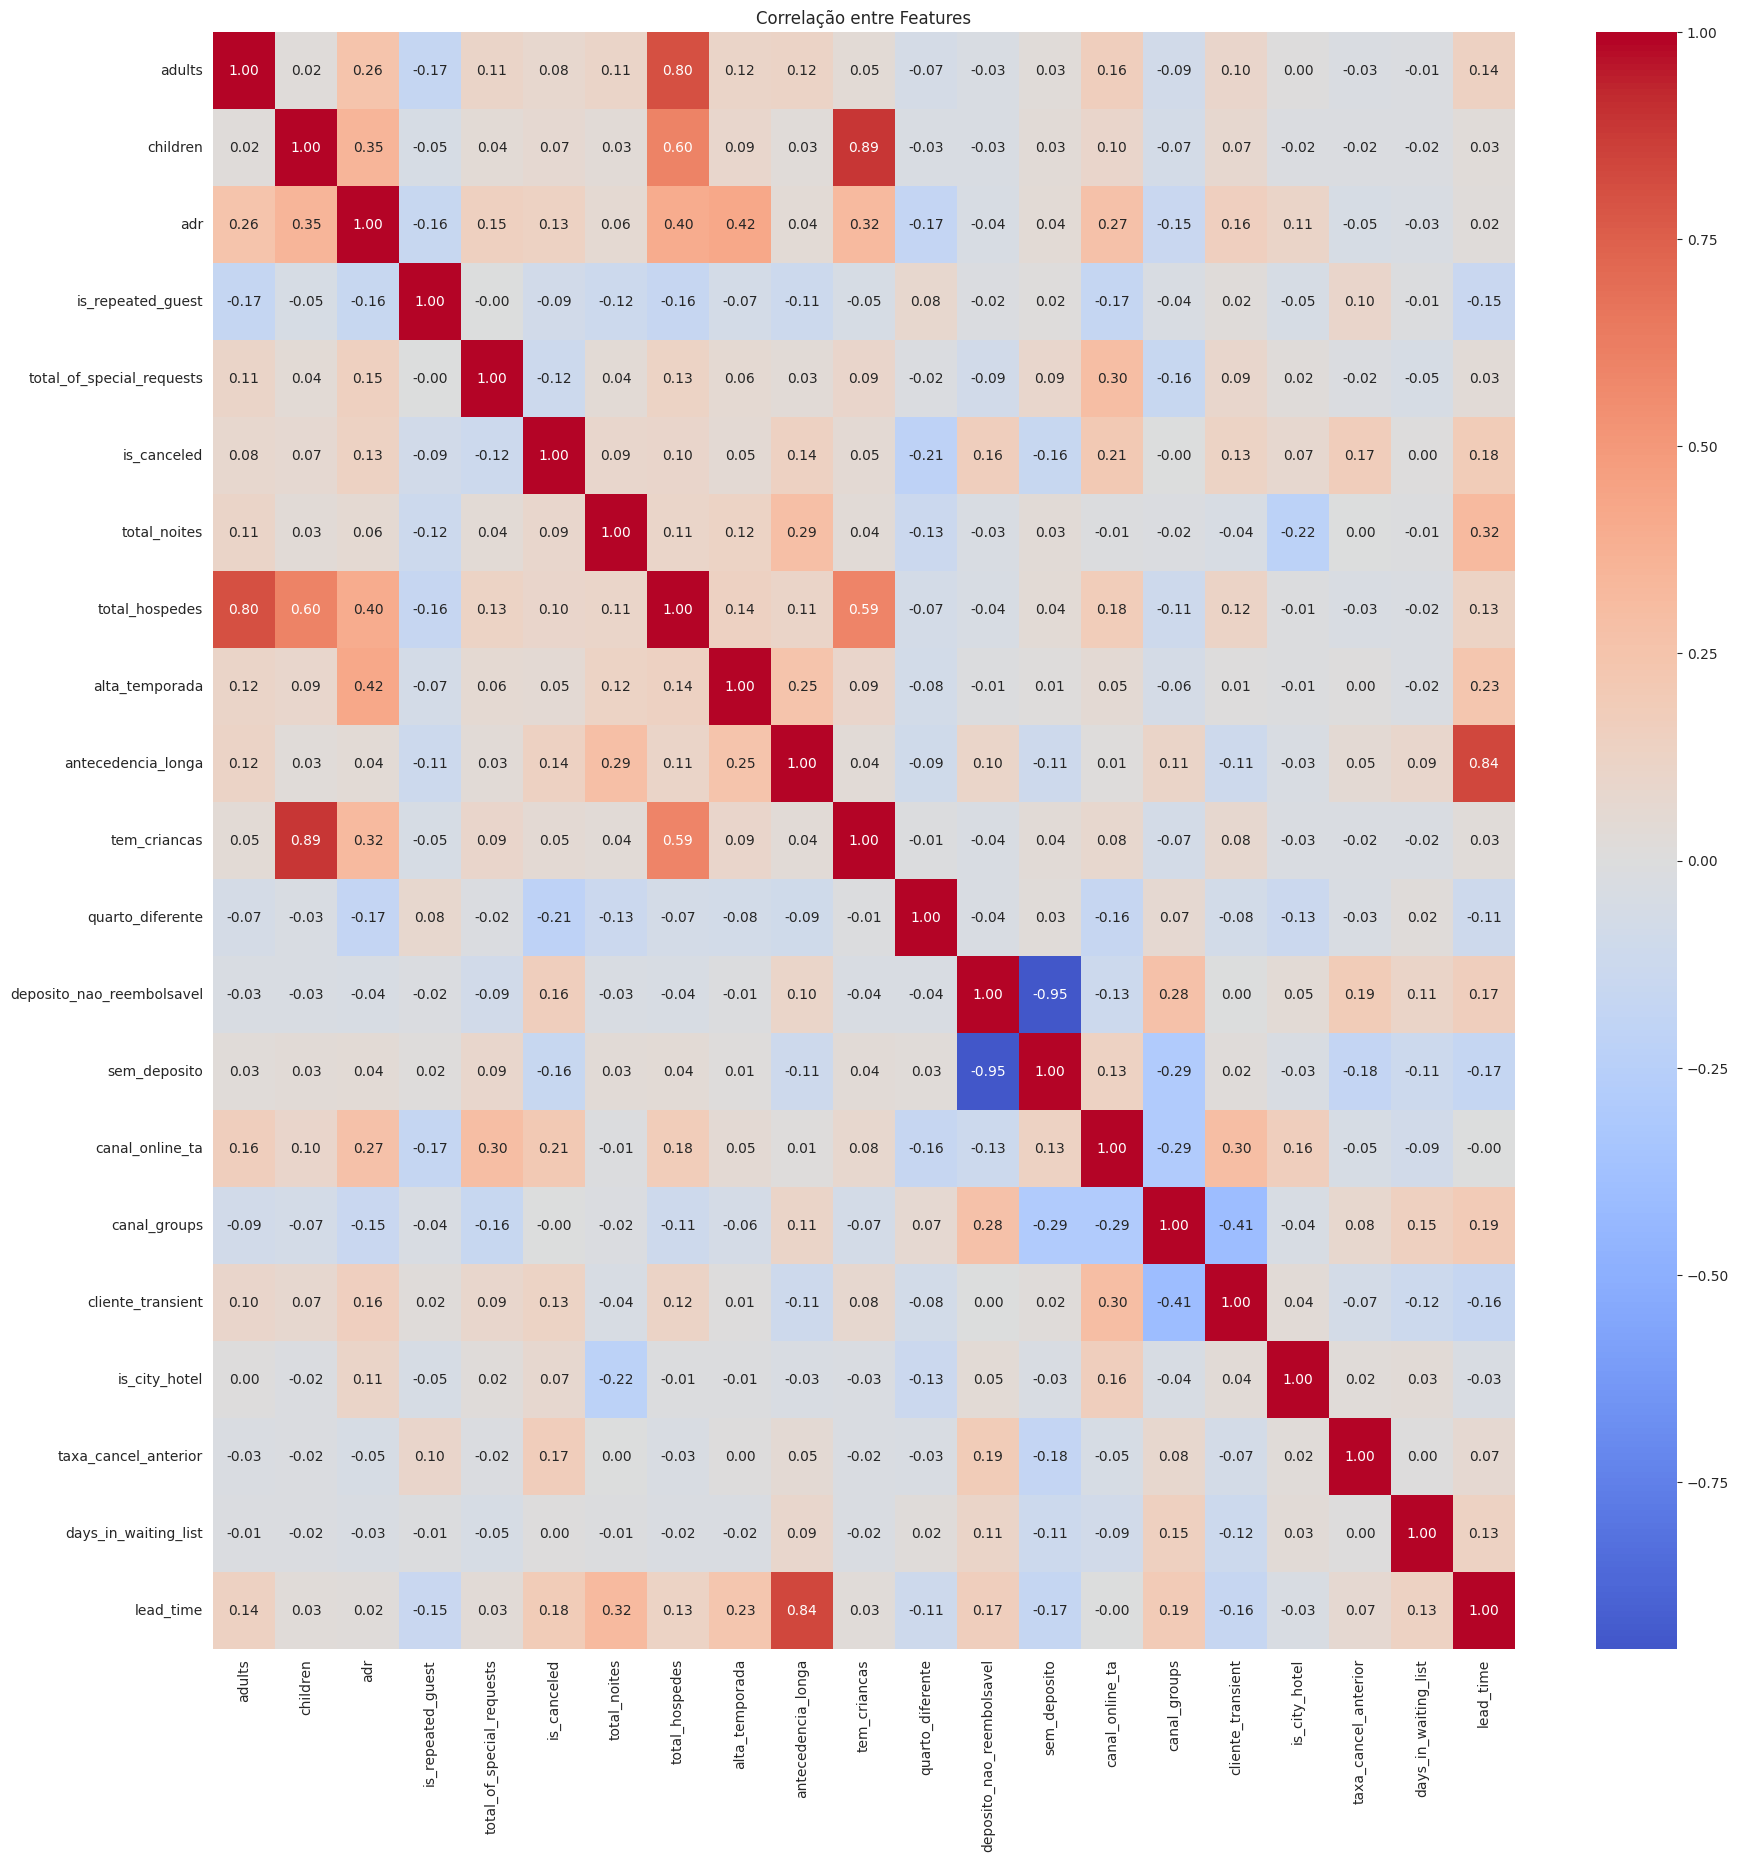

In [18]:
# Análise gráfica de correlação entre colunas Features preparadas
# Criar um novo heatmap APENAS com as novas colunas features

features_corr = [
                'adults', 'children', 'adr', 'is_repeated_guest',
                'total_of_special_requests',
                'is_canceled', "total_noites", "total_hospedes",
                "alta_temporada", "antecedencia_longa", "tem_criancas",
                "quarto_diferente", "deposito_nao_reembolsavel",
                "sem_deposito", "canal_online_ta", "canal_groups",
                "cliente_transient", "is_city_hotel", "taxa_cancel_anterior",
                "days_in_waiting_list", 'lead_time']


numero_de_features = len(features_corr)
plt.figure(figsize=(numero_de_features, numero_de_features))
sns.heatmap((df[features_corr]).corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlação entre Features")
plt.show()

Com base no heatmap montado, que demonstra a correlação entre os dados, separei três informações importantes:

1) "lead_time" tem correlação positiva (0.18) com "is_canceled": quanto maior antecedência da reserva feita, maior é a chance da reserva ser cancelada.

2) "total_of_special_requests" tem correlação negativa (-0.12) com "is_canceled": hóspedes que fazem pedidos especiais cancelam com menos frequência.

3) "is_repeated_guest" tem correlação negativa (-0.09) com "is_canceled": hóspedes que são frequentes no hotel tendem a cancelar menos as suas reservas.

4) "canal_online_ta" possui uma correlação positiva (0.21) com "is_canceled": clientes que fizeram suas reservas pelo canal online têm maior chance de cancelamento.

5) "clinte_transient" possui correlação positiva (0.13) com "is_canceled": Clientes transientes cancelam com um pouco mais de frequência.

6) "deposito_nao_reembolsavel" tem correlação positiva (0.16) com "is_canceled": Reservas com depósito não reembolsável têm taxa de cancelamento maior.

In [19]:
features = ['lead_time', 'total_noites', 'total_hospedes', 'adr', 'numero_mes',
            'alta_temporada', 'antecedencia_longa', 'is_repeated_guest',
            'total_of_special_requests',
            'tem_criancas', 'quarto_diferente',
            'deposito_nao_reembolsavel', 'sem_deposito',
            'canal_online_ta', 'canal_groups', 'cliente_transient',
            'booking_changes', 'days_in_waiting_list',
            'required_car_parking_spaces',
            'is_city_hotel', 'taxa_cancel_anterior']

X = df[features]
y = df['is_canceled']# Target do modelo: 'is_canceled (0 ou 1)

In [20]:
# Divisão dos dados de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [21]:
print(f"Features: {len(features)}")
print(f"Dados de treino: {X_train.shape[0]} reservas ({X_train.shape[0]/len(X)*100:.2f}%)")
print(f"Dados de teste: {X_test.shape[0]} reservas ({X_test.shape[0]/len(X)*100:.2f}%)")
print(f"\nDistribuição do target:")
print(f"   Mantidas: {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"   Canceladas: {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

baseline = (y_test.value_counts().max() / len(y_test)) * 100
print(f"\nBaseline: {baseline:.2f}%")


Features: 21
Dados de treino: 69782 reservas (80.00%)
Dados de teste: 17446 reservas (20.00%)

Distribuição do target:
   Mantidas: 63220 (72.5%)
   Canceladas: 24008 (27.5%)

Baseline: 72.48%


In [22]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=25, min_samples_leaf=3, random_state=42, n_jobs=-1)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=25, min_samples_leaf=3, n_estimators=300,
                       n_jobs=-1, random_state=42)

In [23]:
y_pred_rf = rf.predict(X_test)
acuracia_rf = accuracy_score(y_test, y_pred_rf)

In [24]:
print("==== Avaliação do Modelo ====")
print(f"Baseline: {baseline:.2f}%")
print(f"Acurácia do modelo Random Forest (300 árvores): {(acuracia_rf * 100):.2f}%")

classificacao = classification_report(y_test, y_pred_rf)
print(f"\nClassificação: \n{classificacao}")

==== Avaliação do Modelo ====
Baseline: 72.48%
Acurácia do modelo Random Forest (300 árvores): 81.69%

Classificação: 
              precision    recall  f1-score   support

           0       0.84      0.93      0.88     12644
           1       0.74      0.52      0.61      4802

    accuracy                           0.82     17446
   macro avg       0.79      0.73      0.75     17446
weighted avg       0.81      0.82      0.81     17446



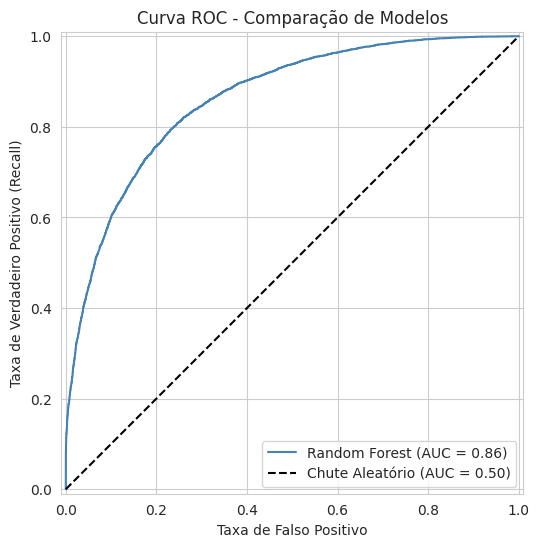

AUC do modelo Random Forest: 0.8622


In [25]:
# Curva ROC
fig, ax = plt.subplots(figsize=(8, 6))

# Plotar Curva ROC do modelo
RocCurveDisplay.from_estimator(rf, X_test, y_test, ax=ax, name='Random Forest', color='steelblue')

# Linha de referência
ax.plot(
    [0, 1], [0, 1], 'k--', label='Chute Aleatório (AUC = 0.50)'
)

ax.set_title("Curva ROC - Comparação de Modelos")
ax.set_xlabel("Taxa de Falso Positivo")
ax.set_ylabel("Taxa de Verdadeiro Positivo (Recall)")
ax.legend(loc='lower right')

plt.show()


# AUC numérico
auc_rf = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])

print(f"AUC do modelo Random Forest: {auc_rf:.4f}")

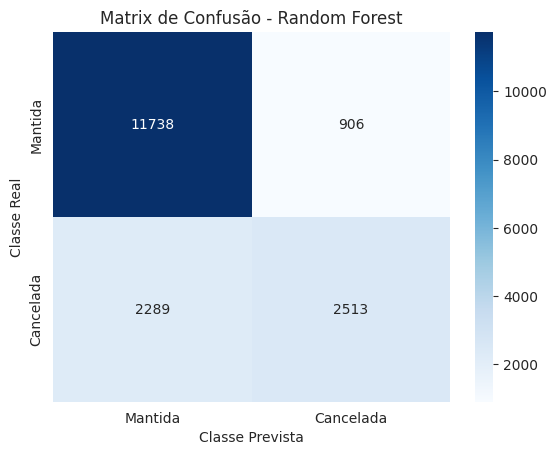

In [26]:
# Matrix de Confusão
matriz = confusion_matrix(y_test, y_pred_rf)

# Construção do gráfico da matrix de Confusão
sns.heatmap(matriz,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["Mantida", "Cancelada"],
            yticklabels=["Mantida", "Cancelada"])

plt.title("Matrix de Confusão - Random Forest")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.show()

De acordo com a matriz de confusão acima, o modelo treinado apresentou:
- Verdadeiros Negativos (VN) = 11.752 -> Não foram canceladas e o modelo previu corretamente como Mantidas.
- Falsos Positivos (FP) = 892 -> Foram mantidas, mas o modelo previu que seram canceladas.
- Verdadeiros Positivos (VP) = 2.482 -> Reservas canceladas onde o modelo previu corretamente o cancelamento.
- Falsos Negativos (FN) = 2.320 -> Foram canceladas, mas o modelo previu que seriam mantidas.

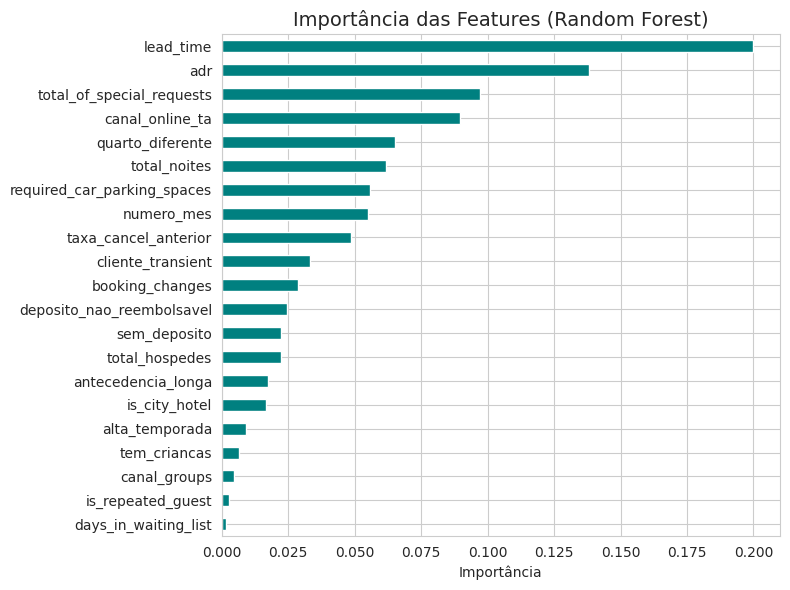

Top 5 features mais importantes:
    1.  lead_time: 0.2000
    2.  adr: 0.1380
    3.  total_of_special_requests: 0.0971
    4.  canal_online_ta: 0.0895
    5.  quarto_diferente: 0.0653


In [27]:
importancias = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importancias.plot(kind='barh', color='teal')
plt.title("Importância das Features (Random Forest)", fontsize=14)
plt.xlabel("Importância")
plt.tight_layout()
plt.show()

print("Top 5 features mais importantes:")
for i, (feat, imp) in enumerate(importancias.sort_values(ascending=False).head().items(), 1):
  print(f"    {i}.  {feat}: {imp:.4f}")

In [28]:
amostra = X_test.head(10).copy()
amostra['Real'] = y_test.head(10).values
amostra['Previsto'] = rf.predict(X_test.head(10))
amostra['Real'] = amostra['Real'].map({0: "Mantida", 1: "Cancelada"})
amostra['Previsto'] = amostra['Previsto'].map({0: "Mantida", 1: "Cancelada"})
amostra['Acertou?'] = amostra['Real'] == amostra['Previsto']

print("======= 10 EXEMPLOS DE PREDIÇÃO (Random Forest) =======")
print(amostra[['lead_time', 'adr', 'total_noites', 'Real', 'Previsto', 'Acertou?']].to_string(index=False))

print(f"\nAcertos: {amostra['Acertou?'].sum()}/10")

======= 10 EXEMPLOS DE PREDIÇÃO (Random Forest) =======
 lead_time    adr  total_noites      Real  Previsto  Acertou?
        91 127.25             4 Cancelada   Mantida     False
         0 136.00             1   Mantida   Mantida      True
        59 102.56             3 Cancelada   Mantida     False
         0  73.00             1   Mantida   Mantida      True
         7 118.00             1   Mantida   Mantida      True
        15 123.00             2   Mantida Cancelada     False
       157 127.00             3   Mantida   Mantida      True
         0   0.00             0   Mantida   Mantida      True
        22 127.67             3 Cancelada Cancelada      True
       187 105.30             2 Cancelada Cancelada      True

Acertos: 7/10
